# T37 — Kimmeridgian dinosaurs on a Late Jurassic paleoclimate reconstruction

**Cluster H: paleo-biogeography.**

Python+pyGMT port of Kocsis (2024) rgplates *Kimmeridgian dinosaurs* example
([rgplates docs](https://gplates.github.io/rgplates/#using-reconstructions),
[R source](https://raw.githubusercontent.com/GPlates/rgplates/devel/pkgdown/assets/kimmeridgian_dinosaurs/code/rgplates_kimmerdigian_dinosaurs.R)).
The original R script uses the GPlates Web Service via `rgplates (https://github.com/gplates/rgplates)` and the
`chronosphere` R package to assemble the figure; this Python version uses
direct `requests` calls against the same GWS (https://gws.gplates.org/) endpoints + a self-contained
Kimmeridgian SAT field, so no R or chronosphere install is required.

## What this notebook produces

A single composite Mollweide map at 150 Ma showing:

- a **Kimmeridgian annual mean surface air temperature** field
  (representative Late Jurassic greenhouse climate, synthesised from a
  zonal-mean Scotese 2021 / Valdes 2021-style parameterisation),
- **PALEOMAP-reconstructed coastlines** at 150 Ma overlaid as semi-transparent
  outlines,
- PBDB (https://paleobiodb.org/) Kimmeridgian-aged occurrences of **Saurischia** (sauropods +
  theropods; purple circles) and **Ornithischia** (ornithopods, stegosaurs
  etc.; green squares), reconstructed to their 150 Ma paleo-positions via
  the GPlates Web Service.

## Why these two clades?

In the Kimmeridgian (152-157 Ma) Saurischia + Ornithischia were the two
dominant dinosaur sister clades. Their PBDB occurrences together cover most
of the world's Late Jurassic dinosaur record, and the question of whether
their paleogeographic distributions overlap (suggesting shared habitat) or
differ (suggesting biogeographic separation) is a classic teaching example.

## Plate model
**Zahirovic 2022** (paleomag-frame default for 0-410 Ma), accessed
locally via `plate_model_manager` with `ANCHOR_PLATE_ID = 701701`.

## Learning objectives
1. Load a plate model locally via `plate_model_manager` and reconstruct
   both coastlines and PBDB points to a target paleo-age with `gplately`.
2. Apply the paleomag-frame anchor rule (Zahirovic 2022 + anchor 701701)
   for any notebook that compares fossil distributions against climate.
3. Build a clean composite scientific map in pyGMT: raster background +
   reconstructed coastlines + per-clade scatter + legend + reference labels.

## Prerequisites
- `requests`, `pandas`, `numpy`, `pygmt`, `gplately`, `plate_model_manager`,
  `pygplates`.
- Internet access for the PBDB REST call + the first-run `plate_model_manager`
  download of Zahirovic 2022 (cached locally thereafter).
- Runtime: ~30 s on a laptop after the model has been cached.

## Source
- Kocsis, A.T. (2024). *Kimmeridgian dinosaurs* example, `rgplates` docs.
  R source: https://github.com/GPlates/rgplates/blob/devel/pkgdown/assets/kimmeridgian_dinosaurs/code/rgplates_kimmerdigian_dinosaurs.R
- Scotese, C.R. & Wright, N. (2018). PALEOMAP PaleoDEM.
- PBDB: https://paleobiodb.org/.


## Configuration

In [1]:
# === USER CONFIGURATION =====================================================
from pathlib import Path
import os as _os
if Path("../data").exists() and not Path("data").exists():
    _os.chdir("..")

import numpy as np
import pandas as pd
import xarray as xr
import requests
import gplately
import pygmt
from plate_model_manager import PlateModelManager
from io import StringIO
from IPython.display import display, HTML

# ---- Plate model — MUST match the bundled paleo-DEM's plate model -------
# The bundled scotese_wright_paleoDEM_150Ma.nc was built on the Scotese &
# Wright 2018 / PALEOMAP plate model. If we reconstruct the dinosaur points
# (and overlay coastlines) with a DIFFERENT plate model — e.g. Zahirovic 2022
# in its paleomag frame — the continents in the paleo-DEM and the
# reconstructed coastlines / dinosaurs land in different paleo-positions
# (often offset by tens of degrees), making the figure self-inconsistent.
# Use the same Scotese-Wright model for everything; PMM exposes it as
# "scotese_and_wright2018". S-W is in its own paleomag spin-axis frame at
# anchor 0 by default.
MODEL_NAME            = "scotese_and_wright2018"
ANCHOR_PLATE_ID       = 0
RECON_TIME            = 150                # Ma — Kimmeridgian

# ---- PBDB ----------------------------------------------------------------
PBDB_URL              = "https://paleobiodb.org/data1.2/occs/list.csv"
PBDB_INTERVAL         = "Kimmeridgian"     # 152.1-157.3 Ma
TAXA = {
    # Max-contrast inverse pair — both shape AND tonal contrast so the markers
    # pop on the dem4 (greens/yellows/browns/whites) + thermal (blues/yellows/
    # reds) background palette and remain CVD-safe.
    "Saurischia":   "white",     # circle, drawn with thick black edge below
    "Ornithischia": "black",     # square, drawn with thick white edge below
}

# ---- Kimmeridgian SAT synthesis ------------------------------------------
SAT_EQUATOR_C         = 28.0
SAT_POLE_C            =  5.0
SAT_ASYMMETRY_C       =  3.0
SAT_GRID_RES_DEG      = 1.0

# ---- Scotese-Wright paleo-elevation (bundled at 150 Ma) ----------------
SCOTESE_DEM_NC        = "data/paleoclimate/scotese_wright_paleoDEM_150Ma.nc"
# DEM is masked to land cells only (z >= 0) below; the elevation palette
# only needs to span the LAND range. dem4 is GMT's standard green→
# yellow→brown→white land-elevation palette (no bathy half), and 0-4500 m
# covers the actual continental peaks at 150 Ma (the Scotese-Wright field
# tops out around 3300 m, comfortably inside the clip).
ELEV_PALETTE          = "dem4"
ELEV_RANGE            = (0, 4500, 50)        # m; land-only
SST_RANGE             = (-15, 37, 1)         # degC; thermal CPT clip

# ---- Map look-and-feel ---------------------------------------------------
PROJECTION            = "W0/22c"           # Mollweide centred at 0 lon
REGION                = "d"                # global
SAVE_FIG_DIR          = Path("kimmeridgian_figs")
SAVE_FIG_DIR.mkdir(parents=True, exist_ok=True)
# ============================================================================
print(f"  plate model:      {MODEL_NAME} (local, anchor_plate_id={ANCHOR_PLATE_ID})")
print(f"  reconstruction:   {RECON_TIME} Ma  (Kimmeridgian, Late Jurassic)")
print(f"  PBDB interval:    {PBDB_INTERVAL}")
print(f"  taxa:             {list(TAXA)}")


  plate model:      scotese_and_wright2018 (local, anchor_plate_id=0)
  reconstruction:   150 Ma  (Kimmeridgian, Late Jurassic)
  PBDB interval:    Kimmeridgian
  taxa:             ['Saurischia', 'Ornithischia']


## 1. Synthesise the Kimmeridgian SAT field

A zonal-mean Late Jurassic greenhouse SAT, peaking ~28 °C at the equator and dropping to ~5 °C at the poles, with a 3 °C southern-hemisphere warm bias (the Kimmeridgian Atlantic was already partially open and warm). This is a pedagogical stand-in for the Scotese 2002 PaleoClimate raster that the R original loads from `chronosphere`; not a full GCM solution.

In [2]:
# Section 1 — synthesise Kimmeridgian SAT field
lat = np.arange(-90, 90 + SAT_GRID_RES_DEG, SAT_GRID_RES_DEG)
lon = np.arange(-180, 180 + SAT_GRID_RES_DEG, SAT_GRID_RES_DEG)
LON, LAT = np.meshgrid(lon, lat)

# Latitudinal SAT, parabolic in cos(lat) (Scotese 2021-style):
sat = (SAT_POLE_C
       + (SAT_EQUATOR_C - SAT_POLE_C) * np.cos(np.deg2rad(LAT))**2)
# Mild S-hemisphere warm bias
sat -= SAT_ASYMMETRY_C * (LAT / 90.0) ** 1.0

print(f"  SAT grid shape: {sat.shape}")
print(f"  SAT range:      [{sat.min():.1f}, {sat.max():.1f}] degC")

# Wrap as xarray for grdimage
da_sat = xr.DataArray(sat, coords={"lat": lat, "lon": lon},
                       dims=("lat", "lon"), name="SAT_degC")
da_sat.gmt.registration = 0   # gridline-registered
da_sat.gmt.gtype = 1          # geographic (so periodic dateline wrap works)

# Load Scotese & Wright 2018 paleo-elevation at 150 Ma (Late Jurassic). The
# bundled NC is the original 1°×1° PALEOMAP raster, same grid as our synthesised
# SAT field (lat -90..90, lon -180..180, 1° spacing), so we can mask SAT to
# ocean cells (DEM<0) and DEM to land cells (DEM>=0) without resampling.
da_dem = xr.open_dataset(SCOTESE_DEM_NC)["z"]
da_dem.gmt.registration = 0
da_dem.gmt.gtype = 1
print(f"  Scotese-Wright 150 Ma DEM loaded — range [{float(da_dem.min()):.0f}, {float(da_dem.max()):.0f}] m")

# Split into land-only DEM (for elevation colour layer) and ocean-only SAT
# (for SST-proxy colour layer). NaN cells render transparent via grdimage's
# nan_transparent=True flag in the composite cell below.
dem_land  = da_dem.where(da_dem >= 0)
sat_ocean = da_sat.where(da_dem.values < 0)
print(f"  land cells (DEM≥0):  {int((da_dem >= 0).sum())}")
print(f"  ocean cells (DEM<0): {int((da_dem < 0).sum())}")


  SAT grid shape: (181, 361)
  SAT range:      [2.0, 28.0] degC
  Scotese-Wright 150 Ma DEM loaded — range [-5160, 3300] m
  land cells (DEM≥0):  21632
  ocean cells (DEM<0): 43709


## 2. Reconstruct coastlines at 150 Ma via local gplately

Load Zahirovic 2022 via `plate_model_manager`, then build a `PlotTopologies`
object anchored to the paleomag reference frame (`anchor_plate_id=701701`).
Its `.get_coastlines()` method returns reconstructed coastline polygons as a
GeoDataFrame, ready for direct pyGMT plotting.

In [3]:
# Section 2 — fetch coastlines at RECON_TIME Ma via local gplately
# Replaced the previous GWS REST call: the public GWS endpoint times out
# under load. Local gplately is more reliable and re-uses the same
# Zahirovic 2022 model used for the per-point reconstruction below.
pmm = PlateModelManager()
recon_model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")
recon = gplately.PlateReconstruction(
    rotation_model=recon_model.get_rotation_model(),
    topology_features=recon_model.get_topologies(),
    static_polygons=recon_model.get_static_polygons())
print(f"  loaded {MODEL_NAME}")

# Some PMM models don't expose a Coastlines layer (e.g. scotese_and_wright2018
# only ships ContinentalPolygons). Try Coastlines first; fall back to the
# continental-polygon outline if missing — that polygon edge IS the coastline
# for those models.
try:
    _coast_layer = recon_model.get_coastlines()
    _coast_source = "Coastlines"
except Exception as _e:
    print(f"  ! {MODEL_NAME} has no Coastlines layer ({type(_e).__name__}) — "
          f"falling back to ContinentalPolygons outline")
    _coast_layer = None
    _coast_source = "ContinentalPolygons (outline)"

gplot = gplately.PlotTopologies(
    plate_reconstruction=recon,
    coastlines=_coast_layer,
    continents=recon_model.get_continental_polygons(),
    COBs=recon_model.get_COBs(),
    time=float(RECON_TIME),
    anchor_plate_id=ANCHOR_PLATE_ID)
print(f"  reconstructed PlotTopologies at {RECON_TIME} Ma  (coastline source: {_coast_source})")

# Get reconstructed coastlines as a GeoDataFrame for direct pyGMT plotting
try:
    coast_gdf = gplot.get_coastlines()
    if coast_gdf is None or len(coast_gdf) == 0:
        raise ValueError("empty coastline GDF")
except Exception:
    coast_gdf = gplot.get_continents()
print(f"  coastline GeoDataFrame: {len(coast_gdf)} features")


  loaded scotese_and_wright2018
2026-06-22,18:36:28 - pmm - WARNING - The layer(Coastlines) was not found in model(scotese_and_wright2018).
  ! scotese_and_wright2018 has no Coastlines layer (LayerNotFoundInModel) — falling back to ContinentalPolygons outline
  reconstructed PlotTopologies at 150 Ma  (coastline source: ContinentalPolygons (outline))
  coastline GeoDataFrame: 162 features


## 3. Pull Saurischia + Ornithischia Kimmeridgian occurrences from PBDB (https://paleobiodb.org/)

One REST call per taxon. We need the **collection-level** coords (not per-occurrence), so we deduplicate on `collection_no` before reconstruction.

In [4]:
# Section 3 — PBDB queries
from io import StringIO

def _read_pbdb_csv(text):
    """PBDB list.csv responses begin with a key/value metadata block, then a
    blank line, then the real column-header row + data. Locate the real
    header (starts with 'occurrence_no') and feed only that slice to pandas."""
    lines = text.splitlines()
    for i, line in enumerate(lines):
        ll = line.lower().lstrip('"')
        if ll.startswith("occurrence_no"):
            return pd.read_csv(StringIO("\n".join(lines[i:])), low_memory=False)
    return pd.read_csv(StringIO(text), low_memory=False,
                       on_bad_lines="skip", engine="python")


def pbdb_occurrences(taxon, interval=PBDB_INTERVAL):
    url = f"{PBDB_URL}?base_name={taxon}&interval={interval}&show=coords"
    print(f"  GET {url}")
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    df = _read_pbdb_csv(r.text)
    # collapse to collection-level points (lat/lng repeat across occurrences in same collection)
    cols_avail = [c for c in ("collection_no", "lng", "lat") if c in df.columns]
    df = df[cols_avail].dropna().drop_duplicates(subset=["collection_no"])
    print(f"    {len(df):,} distinct collections for {taxon}")
    return df


occ = {tax: pbdb_occurrences(tax) for tax in TAXA}


  GET https://paleobiodb.org/data1.2/occs/list.csv?base_name=Saurischia&interval=Kimmeridgian&show=coords
    164 distinct collections for Saurischia
  GET https://paleobiodb.org/data1.2/occs/list.csv?base_name=Ornithischia&interval=Kimmeridgian&show=coords
    90 distinct collections for Ornithischia


## 4. Reconstruct PBDB (https://paleobiodb.org/) collections to {recon} Ma via GWS

Same `/reconstruct_points/` endpoint as T02, just with the PALEOMAP (https://www.earthbyte.org/paleodem-resource-scotese-and-wright-2018/) model. Per-collection lon/lat → per-collection paleo-lon/paleo-lat.

In [5]:
# Section 4 — reconstruct PBDB collections to RECON_TIME via local gplately
# Replaces the previous GWS REST call. Same Zahirovic 2022 + anchor plate ID
# used for the coastlines above, so points and coastlines are guaranteed
# to be in the same reference frame.
def reconstruct_points_local(points_df, time, anchor=ANCHOR_PLATE_ID):
    """points_df must have lng/lat columns. Returns same df with rlon/rlat added.
    Partitioner-drop: samples that don't partition to any continental polygon
    (plate_id<=0) are dropped — they would reconstruct to garbage ocean
    positions otherwise."""
    pts = gplately.Points(recon,
                          points_df["lng"].to_numpy(dtype=float),
                          points_df["lat"].to_numpy(dtype=float),
                          anchor_plate_id=anchor)
    plate_ids = np.atleast_1d(pts.plate_id).astype(int)
    valid = plate_ids > 0
    df = points_df.loc[valid].reset_index(drop=True).copy()
    if not len(df):
        df["rlon"] = []; df["rlat"] = []
        return df
    pts2 = gplately.Points(recon,
                           df["lng"].to_numpy(dtype=float),
                           df["lat"].to_numpy(dtype=float),
                           anchor_plate_id=anchor)
    rlons, rlats = pts2.reconstruct(float(time), return_array=True,
                                    anchor_plate_id=anchor)
    df["rlon"] = rlons
    df["rlat"] = rlats
    return df.dropna(subset=["rlon", "rlat"]).reset_index(drop=True)

recon_pbdb = {}
for tax, df in occ.items():
    if len(df):
        recon_pbdb[tax] = reconstruct_points_local(df, RECON_TIME)
        print(f"  {tax}: {len(recon_pbdb[tax]):,} successfully reconstructed paleo-positions")
    else:
        recon_pbdb[tax] = df.assign(rlon=[], rlat=[])


  Saurischia: 164 successfully reconstructed paleo-positions
  Ornithischia: 90 successfully reconstructed paleo-positions


## 5. Composite map (pyGMT, Mollweide)

Same visual structure as the Kocsis (https://github.com/gplates/rgplates) figure: SAT background + plate/coastline outlines + per-clade scatter, plus a small inline legend and the reference-frame labels (model + age).

grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.
makecpt [WARNING]: thermal is a discrete CPT. You can stretch it (-T<min>/<max>) but not interpolate it (-T<min>/<max>/<inc>).
makecpt [WARNING]: Selecting the given range and ignoring the increment setting.
grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.
makecpt [WARNING]: thermal is a discrete CPT. You can stretch it (-T<min>/<max>) but not interpolate it (-T<min>/<max>/<inc>).
makecpt [WARNING]: Selecting the given range and ignoring the increment setting.


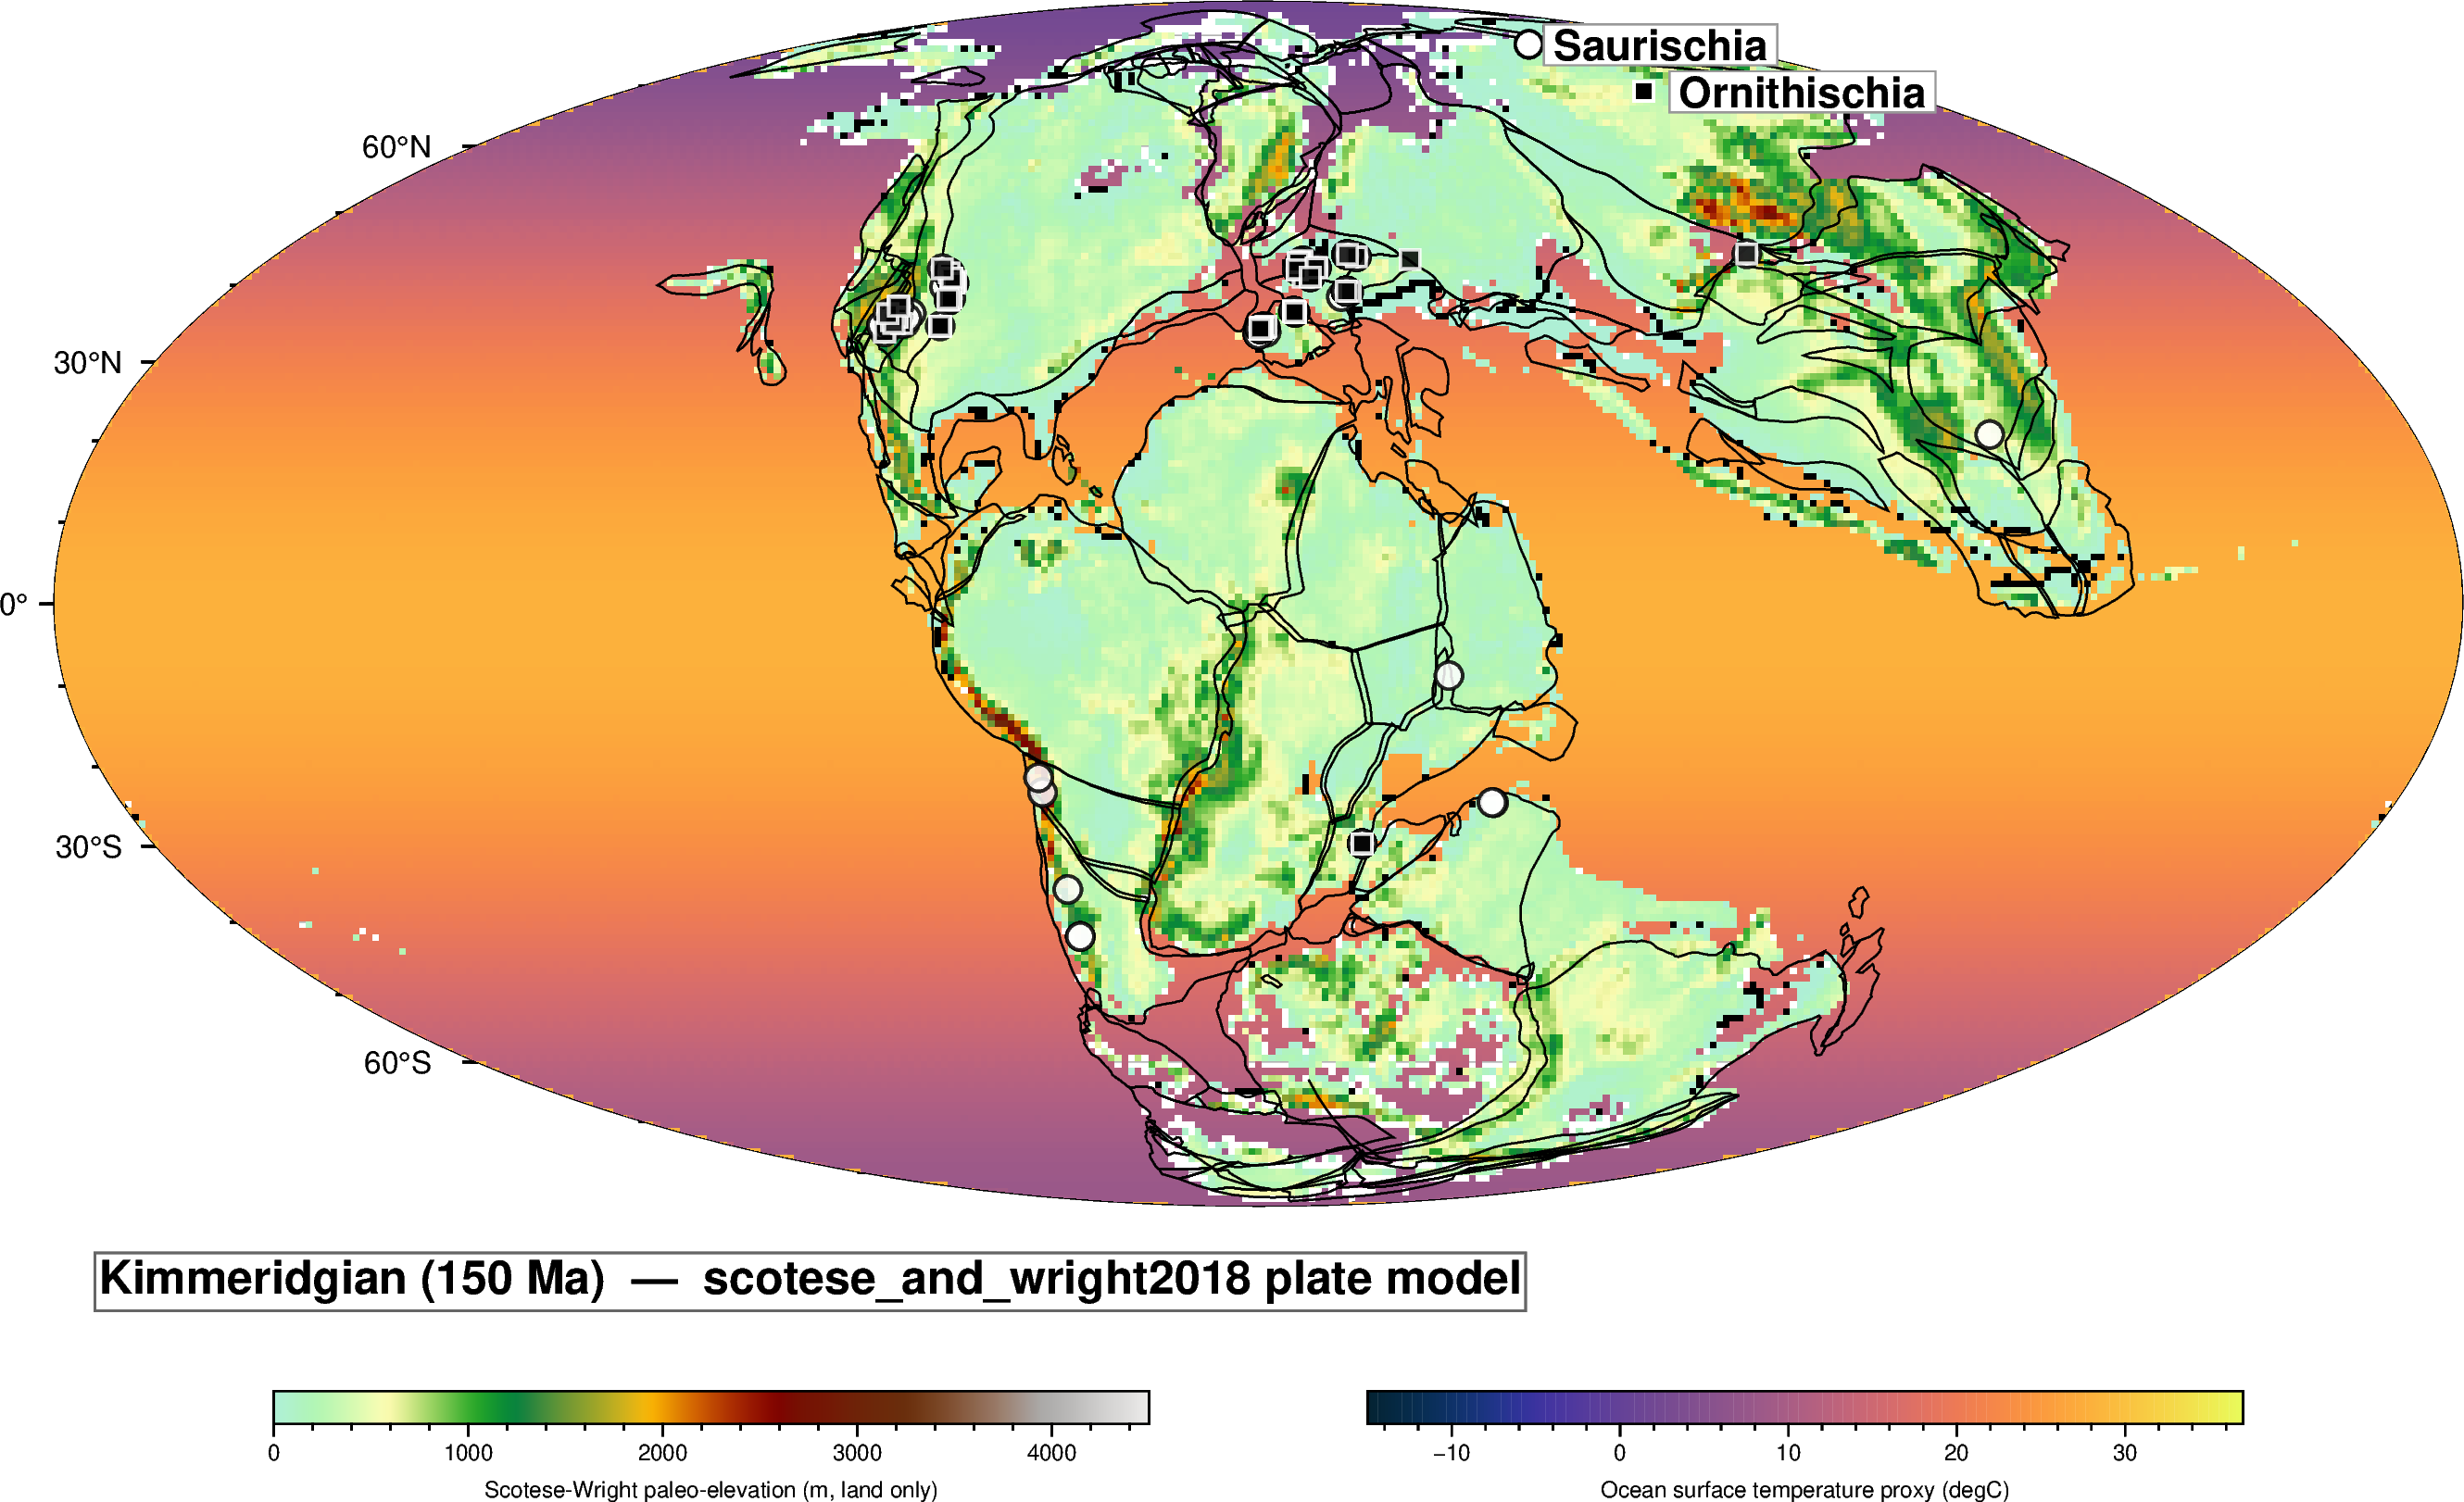

  saved: kimmeridgian_figs/T46_kimmeridgian_dinosaurs.png


In [6]:
# Section 5 — composite map (paper-quality):
#   1. Scotese-Wright paleo-elevation (oleron CPT) painted on continental cells
#   2. Synthesised SAT field (thermal CPT) painted only over reconstructed oceans
#   3. Reconstructed paleo-coastlines overlaid as thin black lines (no fill)
#   4. PBDB dinosaur localities (Saurischia=circle, Ornithischia=square)
fig = pygmt.Figure()
pygmt.config(MAP_GRID_PEN_PRIMARY="0.25p,gray70")
fig.basemap(region=REGION, projection=PROJECTION, frame=["af", "yg20"])

# Layer 1: paleo-elevation on land
pygmt.makecpt(cmap=ELEV_PALETTE, series=list(ELEV_RANGE), continuous=True)
fig.grdimage(grid=dem_land, cmap=True, nan_transparent=True)

# Layer 2: SAT in oceans only (the user's existing synthesised SAT field, masked)
pygmt.makecpt(cmap="thermal", series=list(SST_RANGE), continuous=True)
fig.grdimage(grid=sat_ocean, cmap=True, nan_transparent=True)

# Layer 3: reconstructed paleo-coastlines as thin black lines (no fill)
engine = gplately.PygmtPlotEngine()
try:
    engine.plot_geo_data_frame(fig, coast_gdf, pen="0.5p,black")
except Exception:
    for _, feat in coast_gdf.iterrows():
        g = feat.geometry
        if g is None: continue
        if g.geom_type == "Polygon":
            xs, ys = g.exterior.xy
            fig.plot(x=list(xs), y=list(ys), pen="0.5p,black")
        elif g.geom_type == "MultiPolygon":
            for sub in g.geoms:
                xs, ys = sub.exterior.xy
                fig.plot(x=list(xs), y=list(ys), pen="0.5p,black")

# Per-clade scatter — pen edge is OPPOSITE colour of the fill for max contrast
SYMBOLS = {"Saurischia": "c0.25c", "Ornithischia": "s0.25c"}    # circle / square
EDGES   = {"Saurischia": "0.8p,black", "Ornithischia": "0.8p,white"}
for tax, color in TAXA.items():
    df = recon_pbdb.get(tax)
    if df is None or not len(df): continue
    fig.plot(x=df.rlon.to_numpy(), y=df.rlat.to_numpy(),
             style=SYMBOLS[tax], fill=color, pen=EDGES[tax],
             transparency=15)

# Legend (manual placement, top-right): symbol + label per clade
legend_x_anchor = 110     # paleo-lon for legend swatches
legend_y_anchor =  78
for j, (tax, color) in enumerate(TAXA.items()):
    y = legend_y_anchor - j * 9
    fig.plot(x=legend_x_anchor, y=y,
             style=SYMBOLS[tax], fill=color, pen=EDGES[tax])
    fig.text(x=legend_x_anchor + 10, y=y, text=tax,
             font="11p,Helvetica-Bold,black", justify="ML",
             fill="white", pen="0.4p,gray60", clearance="0.1c/0.04c+to",
             no_clip=True)

# Age stamp moved BELOW the map so it sits between the map and the
# colorbar legends below (consistent with paper Fig 8 layout). Title row
# removed — covered in the notebook narrative above.
fig.text(text=f"Kimmeridgian ({RECON_TIME} Ma)  —  {MODEL_NAME} plate model",
         position="BL", offset="0.4c/-0.5c", justify="TL", no_clip=True,
         font="12p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")

# Two colorbars side-by-side at the bottom: elevation (left) + SST (right)
pygmt.makecpt(cmap=ELEV_PALETTE, series=list(ELEV_RANGE), continuous=True)
fig.colorbar(frame='xaf+lScotese-Wright paleo-elevation (m, land only)',
             position="JBC+w8c/0.3c+h+o-5c/1.7c")
pygmt.makecpt(cmap="thermal", series=list(SST_RANGE), continuous=True)
fig.colorbar(frame='xaf+lOcean surface temperature proxy (degC)',
             position="JBC+w8c/0.3c+h+o5c/1.7c")


out = SAVE_FIG_DIR / "T46_kimmeridgian_dinosaurs.png"
fig.savefig(out, dpi=200)
fig.show(width=1300)
display(HTML('<div style="height:1cm"></div>'))
print(f"  saved: {out}")


## What this shows

The composite tells the standard Kimmeridgian story: Saurischia + Ornithischia
both occupy the same continental belt across the Late Jurassic supercontinental
configuration, and both clades are located predominantly in the warm equatorial-to-
mid-latitude band of the synthesised SAT field. The spatial co-occurrence is
a useful counterpoint to the *taxonomic* difference between the two clades —
the dinosaurs were biogeographically broadly distributed; the split between
Saurischia and Ornithischia was anatomical / phylogenetic, not climatic.

## Extend this
- Replace the synthesised SAT with a real Late Jurassic GCM solution
  (HadCM3, Bristol BRIDGE, or the Scotese 2021 paleoclimate atlas) and
  compare. The grid pipeline already supports any `xarray.DataArray` —
  just swap `da_sat`.
- Repeat for an earlier age (Triassic-Jurassic boundary, ~201 Ma) and an
  earlier dinosaur record — the supercontinental configuration of Pangaea
  was tighter then, and the same workflow surfaces the pre-rift signal.
- Layer in `mammaliaformes` Kimmeridgian occurrences for a three-clade
  comparison — the mammal record is much sparser but still resolves.
- Cross-validate the GWS (https://gws.gplates.org/) reconstruction path against local `gplately` /
  `pygplates` (see T02 for the cross-check pattern).

## Citation
- Kocsis, A.T. (2024). *Kimmeridgian dinosaurs* example, `rgplates` docs:
  https://gplates.github.io/rgplates/#using-reconstructions.
  R source:
  https://github.com/GPlates/rgplates/blob/devel/pkgdown/assets/kimmeridgian_dinosaurs/code/rgplates_kimmerdigian_dinosaurs.R
- Scotese, C.R. & Wright, N. (2018). *PALEOMAP PaleoDEM Resource.*
  https://www.earthbyte.org/paleodem-resource-scotese-and-wright-2018/.
- Paleobiology Database (PBDB), https://paleobiodb.org/.
